# Bakery Demand Forecasting — Data Analysis

This notebook explores and prepares the bakery demand dataset for machine learning.

The main objective is to understand how `Units_Sold` (our demand target)
varies with product, calendar, weather, holidays, and price.

`Units_Produced` and `Leftover` are treated as operational variables and
are not used as inputs for the demand forecasting model.

In [30]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [31]:
# Cell 2 — Load the bakery dataset

# Load the finalized bakery dataset
df = pd.read_csv("../data/bakery_data.csv")

# Convert Date from text into a proper datetime value
df["Date"] = pd.to_datetime(df["Date"])

# Display the first 5 rows
df.head()

,Date,Product,Base_Price_LKR,Units_Produced,Units_Sold,Leftover,Day_of_Week,Month,Season,Is_Weekend,Temperature_C,Rainfall_mm,Weather_Code,Weather_Condition,Is_Holiday,Holiday_Name,Day_Before_Holiday,Day_After_Holiday
0,2024-01-01,Chicken Bun,130,54,49,5,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
1,2024-01-01,Chicken Pastry,180,69,66,3,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
2,2024-01-01,Chicken Samosa,90,63,58,5,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
3,2024-01-01,Cream Bun,120,39,35,4,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False
4,2024-01-01,Egg Roll,100,38,37,1,Monday,1,Northeast Monsoon,False,23.5,11.8,63,Rain,False,NaN,False,False


In [32]:
# Cell 3 — Dataset overview

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nDate range:")
print("Start:", df["Date"].min().date())
print("End:  ", df["Date"].max().date())

print("\nNumber of unique dates:", df["Date"].nunique())

print("\nNumber of products:", df["Product"].nunique())

print("\nProducts:")
print(df["Product"].unique())

Number of rows: 7310
Number of columns: 18

Date range:
Start: 2024-01-01
End:   2025-12-31

Number of unique dates: 731

Number of products: 10

Products:
<ArrowStringArray>
[   'Chicken Bun', 'Chicken Pastry', 'Chicken Samosa',      'Cream Bun',
       'Egg Roll',       'Fish Bun',     'Fish Patty',     'Mini Pizza',
    'Sausage Bun', 'Vegetable Roti']
Length: 10, dtype: str


In [33]:
# Cell 4 — Data structure and basic statistics

# Show column names, data types, and non-null counts
df.info()

print("\nBasic numerical statistics:")
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                7310 non-null   datetime64[us]
 1   Product             7310 non-null   str           
 2   Base_Price_LKR      7310 non-null   int64         
 3   Units_Produced      7310 non-null   int64         
 4   Units_Sold          7310 non-null   int64         
 5   Leftover            7310 non-null   int64         
 6   Day_of_Week         7310 non-null   str           
 7   Month               7310 non-null   int64         
 8   Season              7310 non-null   str           
 9   Is_Weekend          7310 non-null   bool          
 10  Temperature_C       7310 non-null   float64       
 11  Rainfall_mm         7310 non-null   float64       
 12  Weather_Code        7310 non-null   int64         
 13  Weather_Condition   7310 non-null   str           
 14  Is_

,Date,Base_Price_LKR,Units_Produced,Units_Sold,Leftover,Month,Temperature_C,Rainfall_mm,Weather_Code
count,7310,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000
mean,2024-12-31 00:00:00,131.000000,62.598358,57.958687,4.639672,6.519836,24.105472,5.654309,48.257182
min,2024-01-01 00:00:00,90.000000,27.000000,25.000000,0.000000,1.000000,20.400000,0.000000,0.000000
25%,2024-07-01 00:00:00,100.000000,51.000000,48.000000,3.000000,4.000000,23.400000,0.500000,51.000000
50%,2024-12-31 00:00:00,120.000000,61.000000,56.000000,4.000000,7.000000,24.000000,1.900000,53.000000
75%,2025-07-02 00:00:00,140.000000,71.000000,66.000000,6.000000,10.000000,24.600000,5.800000,61.000000
max,2025-12-31 00:00:00,220.000000,139.000000,131.000000,17.000000,12.000000,28.600000,164.900000,65.000000
std,NaN,38.330158,15.900140,14.581110,2.436016,3.449787,1.168145,11.955399,19.728131


In [34]:
# Cell 5 — Data quality checks

# 1. Missing values
print("Missing values by column:")
print(df.isnull().sum())

# 2. Duplicate rows
print("\nDuplicate rows:")
print(df.duplicated().sum())

# 3. Business rule:
# The bakery cannot sell more units than it produced.
production_below_sales = (
    df["Units_Produced"] < df["Units_Sold"]
).sum()

print("\nRows where Units_Produced < Units_Sold:")
print(production_below_sales)

# 4. Leftover should equal produced minus sold
expected_leftover = (
    df["Units_Produced"] - df["Units_Sold"]
)

incorrect_leftover = (
    df["Leftover"] != expected_leftover
).sum()

print("\nRows with incorrect Leftover:")
print(incorrect_leftover)

Missing values by column:
Date                     0
Product                  0
Base_Price_LKR           0
Units_Produced           0
Units_Sold               0
Leftover                 0
Day_of_Week              0
Month                    0
Season                   0
Is_Weekend               0
Temperature_C            0
Rainfall_mm              0
Weather_Code             0
Weather_Condition        0
Is_Holiday               0
Holiday_Name          6790
Day_Before_Holiday       0
Day_After_Holiday        0
dtype: int64

Duplicate rows:
0

Rows where Units_Produced < Units_Sold:
0

Rows with incorrect Leftover:
0


In [35]:
# Cell 6 — Demand statistics by product

product_demand = df.groupby("Product")["Units_Sold"].agg(Mean="mean", Median="median", Std_Dev="std", Minimum="min", Maximum="max").sort_values("Mean", ascending=False)

product_demand

,Mean,Median,Std_Dev,Minimum,Maximum
Product,,,,,
Chicken Pastry,83.170999,83.0,13.063681,52,131
Fish Bun,69.281806,69.0,10.013686,43,125
Chicken Samosa,64.288646,64.0,8.833009,39,107
Chicken Bun,60.445964,61.0,9.284441,37,104
Egg Roll,56.389877,56.0,8.217579,36,82
Sausage Bun,55.392613,56.0,8.327897,36,88
Vegetable Roti,53.255814,53.0,7.338318,33,79
Fish Patty,50.986320,51.0,7.247660,33,75
Cream Bun,45.146375,45.0,7.559204,30,72


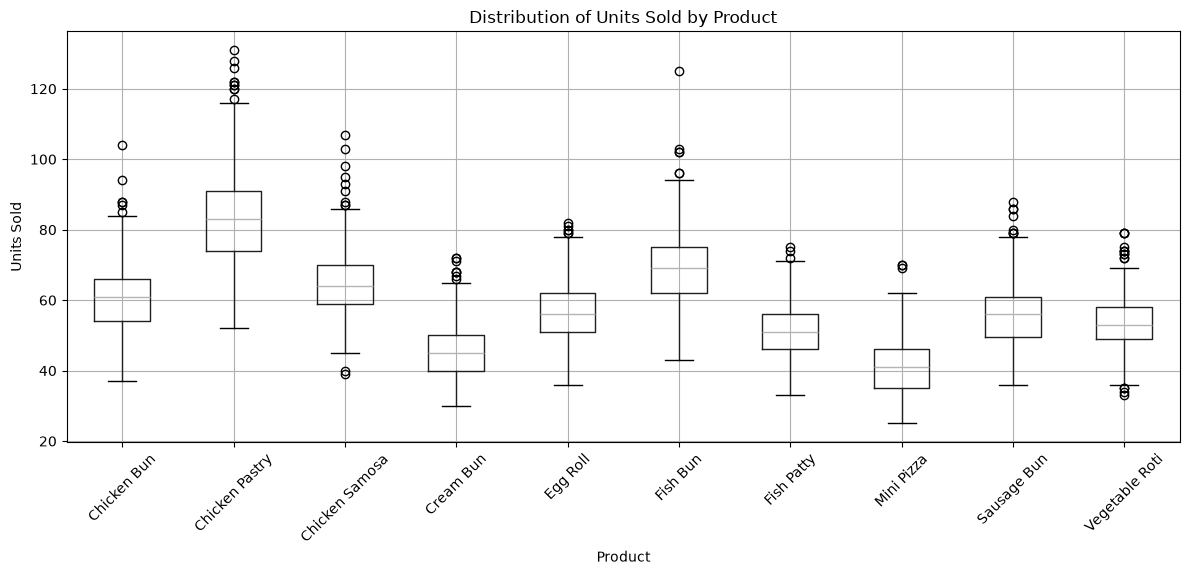

In [38]:
# Cell 7 — Distribution of Units Sold by product

df.boxplot(column="Units_Sold", by="Product",figsize=(12, 6))

plt.title("Distribution of Units Sold by Product")
plt.suptitle("")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [39]:
# Cell 8 — Demand statistics by day of week

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

day_demand = df.groupby("Day_of_Week")["Units_Sold"].agg(Mean="mean",Median="median", Std_Dev="std",Minimum="min",Maximum="max").reindex(day_order)


day_demand

,Mean,Median,Std_Dev,Minimum,Maximum
Day_of_Week,,,,,
Monday,57.199048,56.0,14.590221,25,121
Tuesday,56.566667,55.0,13.838984,28,105
Wednesday,55.586667,54.0,13.837426,28,117
Thursday,56.218269,55.0,13.922011,27,131
Friday,56.356731,55.0,13.826251,29,102
Saturday,61.081731,59.0,15.061058,31,128
Sunday,62.745192,60.0,15.351871,31,125


In [40]:
# Cell 9 — Demand by product and day of week

product_day_demand = df.groupby(["Product", "Day_of_Week"])["Units_Sold"].mean().unstack().reindex(columns=day_order)

product_day_demand

Day_of_Week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Product,,,,,,,
Chicken Bun,59.628571,59.142857,58.323810,59.125000,58.230769,63.634615,65.076923
Chicken Pastry,82.219048,80.761905,78.857143,80.846154,81.721154,87.365385,90.500000
Chicken Samosa,63.200000,62.800000,62.028571,62.000000,63.048077,68.076923,68.913462
Cream Bun,44.152381,43.476190,42.609524,43.490385,43.567308,48.711538,50.067308
Egg Roll,56.238095,55.238095,54.314286,55.250000,55.144231,58.355769,60.221154
Fish Bun,67.838095,68.028571,67.276190,67.009615,67.230769,72.519231,75.115385
Fish Patty,50.676190,50.161905,48.619048,49.615385,49.971154,53.576923,54.317308
Mini Pizza,40.390476,38.771429,38.609524,39.048077,38.769231,45.894231,47.173077
Sausage Bun,54.742857,54.419048,52.914286,53.778846,54.096154,57.836538,60.000000


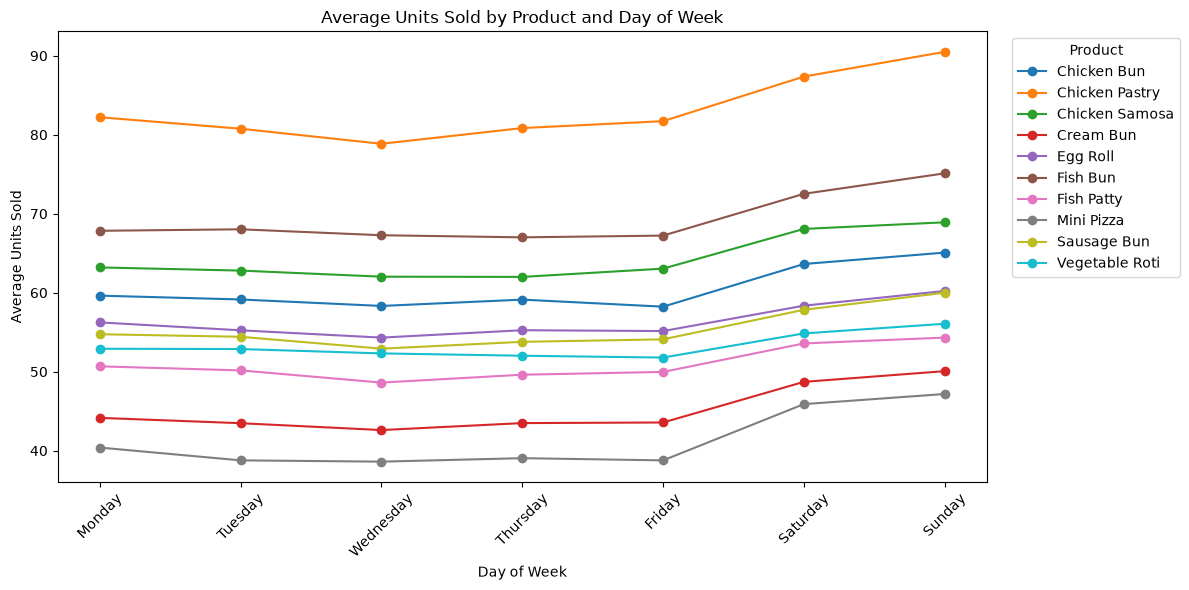

In [41]:
# Cell 10 — Average demand by product and day of week

product_day_demand.T.plot(kind="line", figsize=(12, 6), marker="o")

plt.title("Average Units Sold by Product and Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Units Sold")
plt.xticks(range(7), day_order, rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [42]:
# Cell 11 — Average demand by product and month

month_order = list(range(1, 13))

product_month_demand = df.groupby(["Product", "Month"])["Units_Sold"].mean().unstack().reindex(columns=month_order)

product_month_demand

Month,1,2,3,4,5,6,7,8,9,10,11,12
Product,,,,,,,,,,,,
Chicken Bun,60.032258,63.894737,61.274194,64.733333,56.612903,58.166667,58.370968,59.467742,59.150000,57.774194,56.316667,69.725806
Chicken Pastry,82.645161,87.964912,86.870968,87.616667,78.193548,80.783333,78.919355,81.677419,79.666667,80.177419,78.750000,94.983871
Chicken Samosa,63.354839,66.491228,65.193548,69.283333,61.596774,62.416667,61.806452,63.451613,62.000000,63.048387,60.333333,72.564516
Cream Bun,45.419355,49.052632,46.500000,47.600000,42.354839,43.866667,42.661290,44.903226,43.766667,42.774194,41.966667,51.096774
Egg Roll,56.225806,58.719298,58.693548,59.650000,53.854839,55.100000,54.338710,55.290323,54.350000,54.370968,53.000000,63.161290
Fish Bun,69.193548,72.210526,70.177419,74.583333,65.177419,67.716667,66.290323,67.500000,68.516667,67.741935,64.833333,77.629032
Fish Patty,50.822581,52.578947,51.870968,54.333333,47.629032,49.966667,49.177419,50.580645,50.066667,49.645161,47.833333,57.403226
Mini Pizza,42.370968,45.192982,43.064516,43.700000,38.516129,39.600000,39.306452,39.677419,39.216667,38.709677,38.416667,47.161290
Sausage Bun,55.564516,58.263158,57.129032,59.250000,51.709677,53.350000,52.709677,54.241935,54.133333,53.500000,51.800000,63.193548


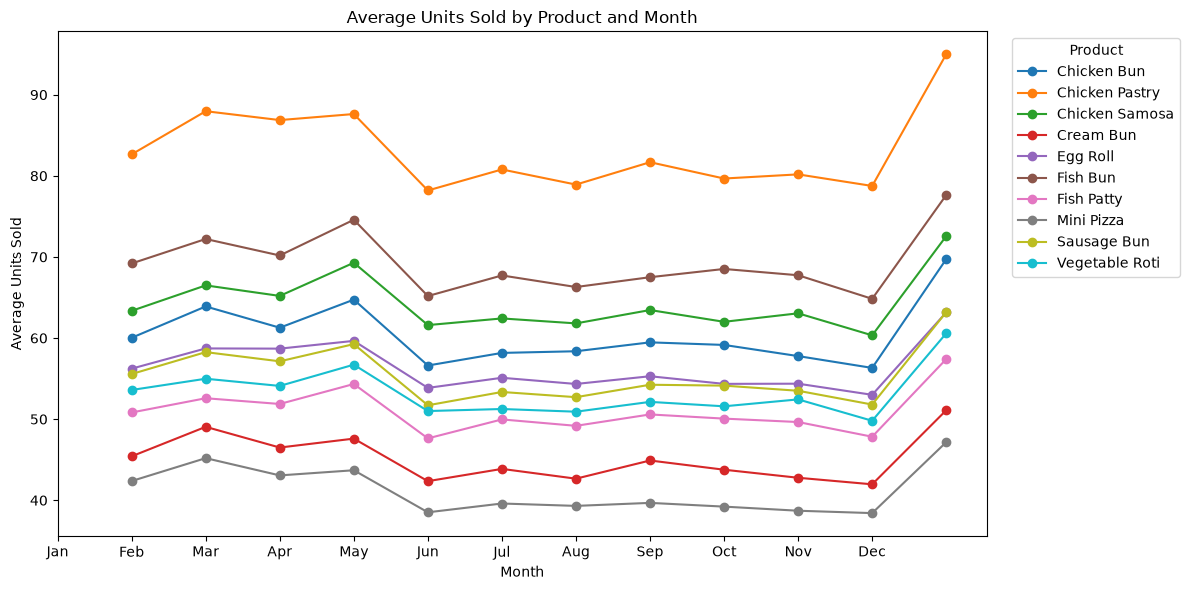

In [43]:
# Cell 12 — Average demand by product and month

product_month_demand.T.plot(kind="line", figsize=(12, 6), marker="o")

plt.title("Average Units Sold by Product and Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.xticks(range(12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                       "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(title="Product", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [44]:
# Cell 13 — Holiday vs non-holiday demand by product

holiday_demand = df.groupby(["Product", "Is_Holiday"])["Units_Sold"].mean().unstack()

holiday_demand.columns = ["Non-Holiday", "Holiday"]

holiday_demand

,Non-Holiday,Holiday
Product,,
Chicken Bun,59.858616,68.115385
Chicken Pastry,82.324006,94.230769
Chicken Samosa,63.843888,70.096154
Cream Bun,44.568483,52.692308
Egg Roll,55.944035,62.211538
Fish Bun,68.609720,78.057692
Fish Patty,50.575847,56.346154
Mini Pizza,40.720177,47.865385
Sausage Bun,54.873343,62.173077


In [45]:
# Cell 14 — Demand around holidays by product

df["Holiday_Period"] = np.select([df["Is_Holiday"], df["Day_Before_Holiday"], df["Day_After_Holiday"]], ["Holiday", "Day Before", "Day After"], default="Normal")

holiday_period_demand = df.groupby(["Product", "Holiday_Period"])["Units_Sold"].mean().unstack()

holiday_period_demand

Holiday_Period,Day After,Day Before,Holiday,Normal
Product,,,,
Chicken Bun,60.714286,61.181818,68.115385,59.699831
Chicken Pastry,87.261905,84.931818,94.230769,81.780776
Chicken Samosa,65.714286,66.045455,70.096154,63.548061
Cream Bun,46.380952,46.954545,52.692308,44.263069
Egg Roll,56.690476,57.863636,62.211538,55.748735
Fish Bun,69.928571,69.590909,78.057692,68.443508
Fish Patty,52.333333,51.840909,56.346154,50.357504
Mini Pizza,42.595238,43.090909,47.865385,40.411467
Sausage Bun,55.857143,57.613636,62.173077,54.600337


In [46]:
# Cell 15 — Rainfall and demand correlation by product

rainfall_correlation = df.groupby("Product").apply(lambda x: x["Rainfall_mm"].corr(x["Units_Sold"]), include_groups=False).sort_values()

rainfall_correlation

Product
Egg Roll         -0.497968
Vegetable Roti   -0.466289
Fish Patty       -0.466059
Fish Bun         -0.459712
Chicken Samosa   -0.456764
Chicken Pastry   -0.443236
Chicken Bun      -0.441817
Sausage Bun      -0.428834
Cream Bun        -0.394871
Mini Pizza       -0.357086
dtype: float64

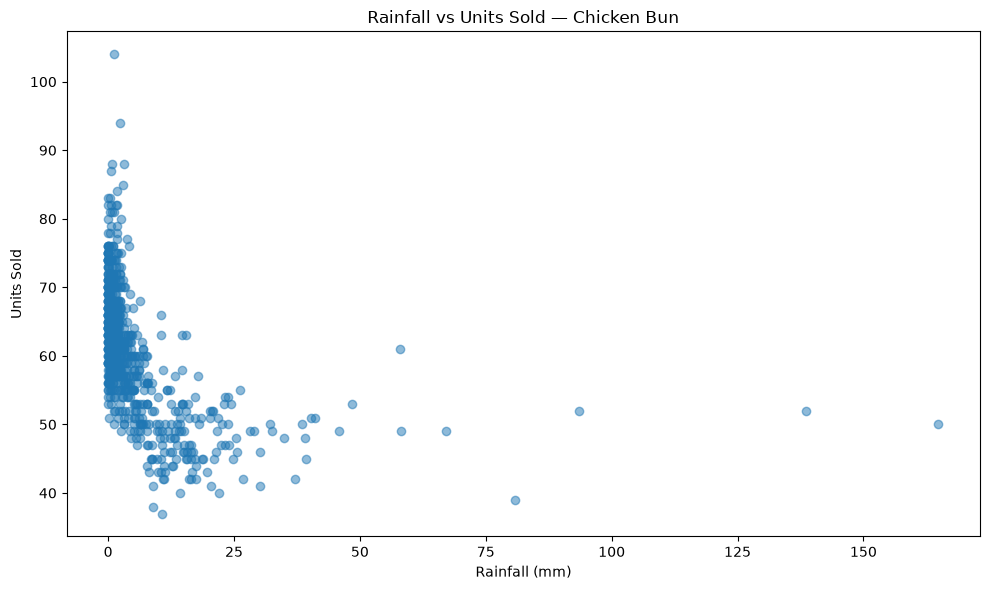

In [47]:
# Cell 16 — Rainfall vs Units Sold for Chicken Bun

chicken_bun = df[df["Product"] == "Chicken Bun"]

plt.figure(figsize=(10, 6))
plt.scatter(chicken_bun["Rainfall_mm"], chicken_bun["Units_Sold"], alpha=0.5)

plt.title("Rainfall vs Units Sold — Chicken Bun")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [48]:
# Cell 17 — Temperature and demand correlation by product

temperature_correlation = df.groupby("Product").apply(lambda x: x["Temperature_C"].corr(x["Units_Sold"]), include_groups=False).sort_values()

temperature_correlation

Product
Vegetable Roti    0.174888
Chicken Bun       0.180812
Chicken Samosa    0.181631
Fish Bun          0.181742
Sausage Bun       0.195333
Cream Bun         0.202977
Egg Roll          0.210593
Mini Pizza        0.211329
Chicken Pastry    0.222208
Fish Patty        0.229981
dtype: float64

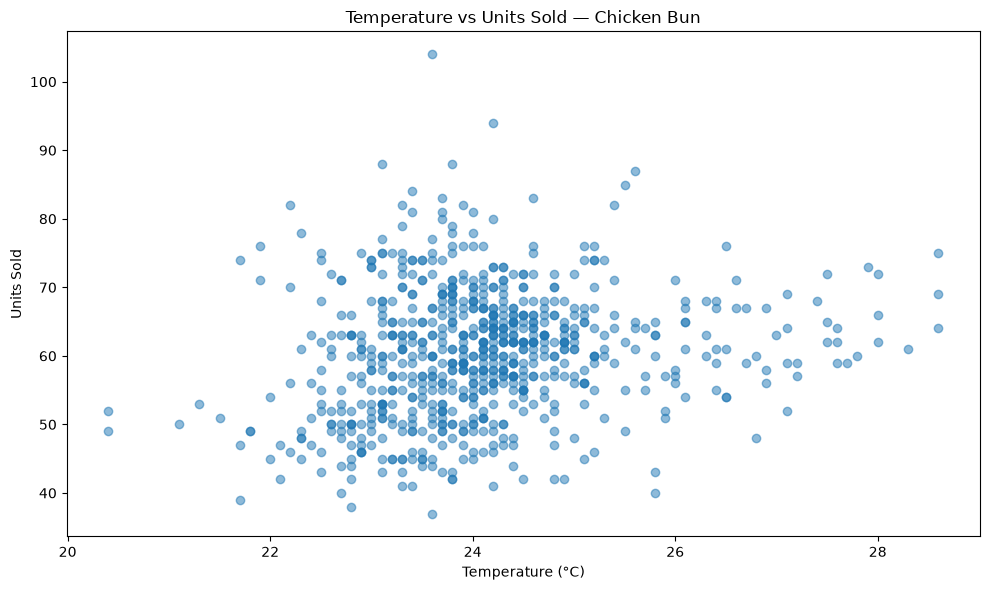

In [49]:
# Cell 18 — Temperature vs Units Sold for Chicken Bun

plt.figure(figsize=(10, 6))
plt.scatter(chicken_bun["Temperature_C"], chicken_bun["Units_Sold"], alpha=0.5)

plt.title("Temperature vs Units Sold — Chicken Bun")
plt.xlabel("Temperature (°C)")
plt.ylabel("Units Sold")

plt.tight_layout()
plt.show()

In [50]:
# Cell 19 — Price variation by product

price_variation = df.groupby("Product")["Base_Price_LKR"].agg(["nunique", "min", "max"])

price_variation

,nunique,min,max
Product,,,
Chicken Bun,1,130,130
Chicken Pastry,1,180,180
Chicken Samosa,1,90,90
Cream Bun,1,120,120
Egg Roll,1,100,100
Fish Bun,1,120,120
Fish Patty,1,110,110
Mini Pizza,1,220,220
Sausage Bun,1,140,140


In [51]:
# Cell 20 — Current price vs demand correlation

price_sales_correlation = df["Base_Price_LKR"].corr(df["Units_Sold"])

print("Price vs Units Sold correlation:", price_sales_correlation)

Price vs Units Sold correlation: -0.03247463566151346


# Time Series Demand Overview

In [52]:
# Cell 21 — Daily total demand over time

daily_demand = df.groupby("Date")["Units_Sold"].sum()

daily_demand.head()

Date
2024-01-01    465
2024-01-02    478
2024-01-03    601
2024-01-04    588
2024-01-05    549
Name: Units_Sold, dtype: int64

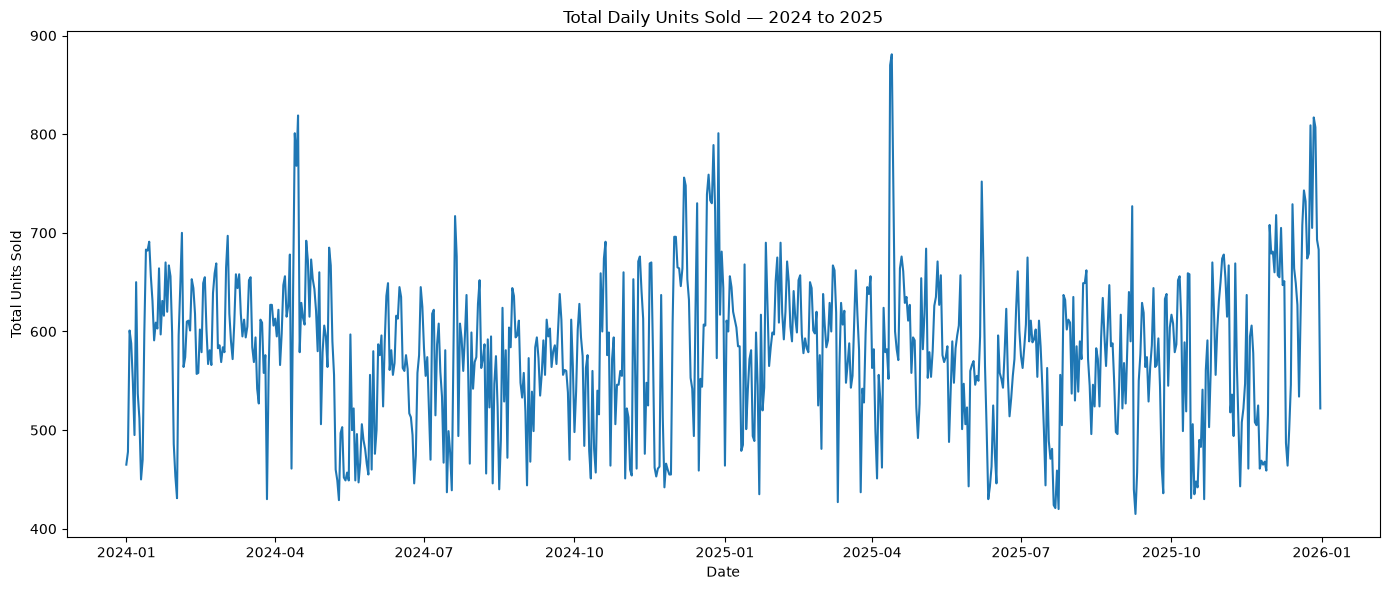

In [53]:
# Cell 22 — Daily total demand over time

plt.figure(figsize=(14, 6))
plt.plot(daily_demand.index, daily_demand.values)

plt.title("Total Daily Units Sold — 2024 to 2025")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")

plt.tight_layout()
plt.show()

In [54]:
# Cell 23 — Highest-demand days

daily_summary = df.groupby("Date").agg(Total_Units_Sold=("Units_Sold", "sum"), Is_Holiday=("Is_Holiday", "first"), Rainfall_mm=("Rainfall_mm", "first"), Temperature_C=("Temperature_C", "first")).sort_values("Total_Units_Sold", ascending=False)

daily_summary.head(15)

,Total_Units_Sold,Is_Holiday,Rainfall_mm,Temperature_C
Date,,,,
2025-04-13,881,True,2.4,24.2
2025-04-12,870,True,1.2,23.6
2024-04-15,819,True,0.6,25.6
2025-12-27,817,False,1.8,23.4
2025-12-25,809,True,0.0,23.1
2025-12-28,807,False,0.5,23.8
2024-04-13,801,True,3.0,25.5
2024-12-28,801,False,0.2,23.9
2024-12-25,789,True,0.0,22.2


In [55]:
# Cell 24 — Extreme demand days with calendar context

daily_summary = df.groupby("Date").agg(Total_Units_Sold=("Units_Sold", "sum"), Day_of_Week=("Day_of_Week", "first"), Is_Weekend=("Is_Weekend", "first"), Is_Holiday=("Is_Holiday", "first"), Day_Before_Holiday=("Day_Before_Holiday", "first"), Day_After_Holiday=("Day_After_Holiday", "first")).sort_values("Total_Units_Sold", ascending=False)

daily_summary.head(15)

,Total_Units_Sold,Day_of_Week,Is_Weekend,Is_Holiday,Day_Before_Holiday,Day_After_Holiday
Date,,,,,,
2025-04-13,881,Sunday,True,True,True,True
2025-04-12,870,Saturday,True,True,True,False
2024-04-15,819,Monday,False,True,False,False
2025-12-27,817,Saturday,True,False,False,False
2025-12-25,809,Thursday,False,True,False,False
2025-12-28,807,Sunday,True,False,False,False
2024-04-13,801,Saturday,True,True,False,True
2024-12-28,801,Saturday,True,False,False,False
2024-12-25,789,Wednesday,False,True,False,False


In [56]:
# Cell 25 — Correlation of candidate numerical features with demand

correlation_columns = ["Base_Price_LKR", "Month", "Is_Weekend", "Temperature_C", "Rainfall_mm", "Weather_Code", "Is_Holiday", "Day_Before_Holiday", "Day_After_Holiday", "Units_Sold"]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix["Units_Sold"].sort_values(ascending=False)

Units_Sold            1.000000
Is_Weekend            0.171057
Is_Holiday            0.134049
Temperature_C         0.119589
Day_After_Holiday     0.050425
Day_Before_Holiday    0.043162
Month                -0.012985
Base_Price_LKR       -0.032475
Weather_Code         -0.248799
Rainfall_mm          -0.265130
Name: Units_Sold, dtype: float64

In [57]:
# Cell 26 — Product demand by year

product_year_demand = df.groupby(["Product", df["Date"].dt.year])["Units_Sold"].mean().unstack()

product_year_demand.columns = ["2024", "2025"]

product_year_demand

,2024,2025
Product,,
Chicken Bun,60.008197,60.884932
Chicken Pastry,83.259563,83.082192
Chicken Samosa,64.032787,64.545205
Cream Bun,45.098361,45.194521
Egg Roll,56.030055,56.750685
Fish Bun,68.920765,69.643836
Fish Patty,51.008197,50.964384
Mini Pizza,41.330601,41.126027
Sausage Bun,55.013661,55.772603


In [58]:
# Cell 27 — Year-over-year demand change

year_change = ((product_year_demand["2025"] - product_year_demand["2024"]) / product_year_demand["2024"] * 100).round(2)

year_change.sort_values(ascending=False)

Product
Chicken Bun       1.46
Sausage Bun       1.38
Egg Roll          1.29
Fish Bun          1.05
Chicken Samosa    0.80
Vegetable Roti    0.54
Cream Bun         0.21
Fish Patty       -0.09
Chicken Pastry   -0.21
Mini Pizza       -0.49
dtype: float64

In [59]:
# Cell 28 — Final EDA summary

print("Target: Units_Sold")
print("Rows:", len(df))
print("Products:", df["Product"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())

print("\nCandidate model inputs:")
print("Product")
print("Day_of_Week")
print("Month / Season")
print("Is_Weekend")
print("Is_Holiday")
print("Day_Before_Holiday")
print("Day_After_Holiday")
print("Temperature_C")
print("Rainfall_mm")
print("Weather_Condition")
print("Base_Price_LKR")

print("\nExcluded from prediction:")
print("Units_Produced")
print("Leftover")

Target: Units_Sold
Rows: 7310
Products: 10
Date range: 2024-01-01 to 2025-12-31

Candidate model inputs:
Product
Day_of_Week
Month / Season
Is_Weekend
Is_Holiday
Day_Before_Holiday
Day_After_Holiday
Temperature_C
Rainfall_mm
Weather_Condition
Base_Price_LKR

Excluded from prediction:
Units_Produced
Leftover
